<a href="https://colab.research.google.com/github/23kq1a5413-ai/Customer-Segmentation-using-RFM-Analysis-/blob/main/Customer_Segmentation_using_RFM_Analysis_ipynd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

 Upload Dataset

In [14]:
df = pd.read_csv("/content/OnlineRetail.csv", encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Check Missing Values

In [15]:
print(df.isnull().sum())

InvoiceNo          0
StockCode          0
Description     1085
Quantity           0
InvoiceDate        0
UnitPrice          1
CustomerID     81652
Country            1
dtype: int64


Remove Missing Values

In [16]:
df = df.dropna(subset=["CustomerID"])

print(df.shape)

(207055, 8)


Create Total Amount Column

In [17]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


Convert Date

In [18]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].head())

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


RFM Analysis

In [19]:
today = df["InvoiceDate"].max()

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (today - x.max()).days,
    "InvoiceNo": "count",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         197          2      0.00
12347.0           1        124   2790.86
12348.0         120         28   1487.24
12350.0         181         17    334.40
12352.0         133         48    601.18


Customer Segmentation Logic

In [20]:
def segment(row):
    if row["Monetary"] > 5000:
        return "High Value"
    elif row["Recency"] > 30:
        return "At Risk"
    else:
        return "New Customer"

rfm["Segment"] = rfm.apply(segment, axis=1)

print(rfm.head(10))

            Recency  Frequency  Monetary       Segment
CustomerID                                            
12346.0         197          2      0.00       At Risk
12347.0           1        124   2790.86  New Customer
12348.0         120         28   1487.24       At Risk
12350.0         181         17    334.40       At Risk
12352.0         133         48    601.18       At Risk
12353.0          75          4     89.00       At Risk
12354.0         103         58   1079.40       At Risk
12355.0          85         13    459.40       At Risk
12356.0         117         57   2753.08       At Risk
12358.0          22         12    484.86  New Customer


Bar Chart

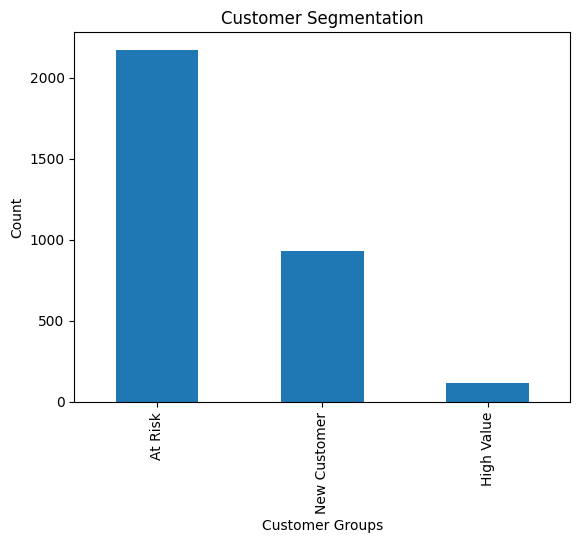

In [21]:
rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Customer Groups")
plt.ylabel("Count")

plt.show()

Revenue Pie Chart

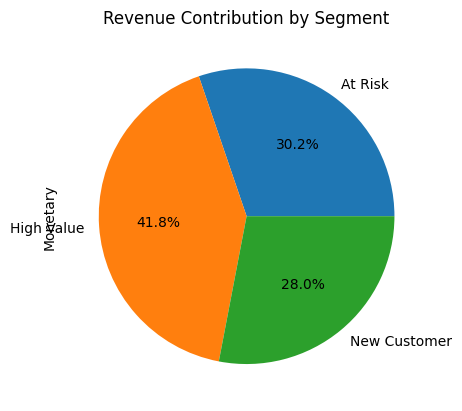

In [22]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum()

segment_revenue.plot(kind="pie", autopct="%1.1f%%")

plt.title("Revenue Contribution by Segment")

plt.show()
